In [9]:
import kwant
import tinyarray as ta
import numpy as np
import types
import matplotlib.pyplot as plt

In [10]:
from pathlib import Path
Path('zad_1').mkdir(exist_ok=True)

In [ ]:
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"""
\usepackage[T1]{fontenc}
\usepackage[utf8]{inputenc}
\usepackage[polish]{babel}
\usepackage{lmodern}
\usepackage{amsmath}
\usepackage{amssymb}
\usepackage{physics}
"""

plt.rcParams.update({
    # ===== Font =====
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ===== Sizes =====
    "font.size": 16,
    "axes.labelsize": 22,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,

    # ===== Lines =====
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.5,

    # ===== Ticks =====
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # ===== Figure =====
    "figure.figsize": (10, 7),
    "figure.dpi": 300,

    # ===== Save =====
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # ===== Legend =====
    "legend.frameon": False,
    "legend.fancybox": False,
})

In [12]:
# Konwersja jednostek
def eV_to_au(e):   
    return e * 0.03674932587122423

def nm_to_au(x):   
    return x * 18.89726133921252

def T_to_au(b):    
    return b * 4.254382e-6

MU_B = 0.5   # magneton Bohra w j.a.

# Macierze Pauliego 
sx = ta.array([[ 0 , 1 ], 
               [ 1 , 0 ]])

sy = ta.array([[ 0 ,-1j], 
               [ 1j, 0 ]])

sz = ta.array([[ 1 , 0 ], 
               [ 0 ,-1 ]])

# Macierz do rozróżnienia orbitali w kontakcie 
conservation_law_matrix = ta.array([[1, 0], 
                                    [0, 2]])

## Układ

In [ ]:
def build_system(params):
    dx  = params.dx
    L   = params.L
    W   = params.W
    m   = params.m
    g   = params.g
    alpha = params.alpha
    Bx, By, Bz   = params.B
    x0, x1, y0, y1 = params.area
    aBx, aBy, aBz  = params.aB
 
    t_hop = 1.0 / (2.0 * m * dx * dx)
    t_so  = alpha / (2.0 * dx)
 
    def onsite(site):
        x, y = site.pos
        in_region = (
            1 if params.add_aB
            and x0 * L * dx <= x <= x1 * L * dx
            and y0 * W * dx <= y <= y1 * W * dx
            else 0
        )
        zeeman = 0.5 * g * MU_B * (
            (Bx + in_region * aBx) * sx +
            (By + in_region * aBy) * sy +
            (Bz + in_region * aBz) * sz
        Par)
        return ta.identity(2) * 4 * t_hop + zeeman
 
    def onsite_lead(site):
        zeeman = 0.5 * g * MU_B * (Bx * sx + By * sy + Bz * sz)
        return ta.identity(2) * 4 * t_hop + zeeman
 
    def hop_x(si, sj):
        xi, _ = si.pos
        xj, _ = sj.pos
        sign = 1 if xj > xi else -1
        return -ta.identity(2) * t_hop + 1j * sy * t_so * sign
 
    def hop_y(si, sj):
        _, yi = si.pos
        _, yj = sj.pos
        sign = -1 if yj > yi else 1
        return -ta.identity(2) * t_hop + 1j * sx * t_so * sign
 
    lat = kwant.lattice.square(dx, norbs=2)
    sys = kwant.Builder()
 
    sys[(lat(i, j) for i in range(L) for j in range(W))] = onsite
    sys[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    sys[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
 
    # dolaczam lewy kontakt
    left_lead = kwant.Builder(
        kwant.TranslationalSymmetry((-dx, 0)),
        conservation_law=conservation_law_matrix
    )
    left_lead[(lat(i, j) for i in range(L) for j in range(W))] = onsite_lead
    left_lead[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    left_lead[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
 
    # dolaczam prawy kontakt - jest lustrzanym odbiciem lewego
    sys.attach_lead(left_lead)
    sys.attach_lead(left_lead.reversed()) 
 
    return sys.finalized()

## Funkcje

In [15]:
def compute_dispersion(params, lead_idx=0, k_max=0.15, nk=201):
    sys     = build_system(params)
    dx      = params.dx
    momenta = np.linspace(-k_max, k_max, nk) * dx / nm_to_au(1.0)
    bands   = kwant.physics.Bands(sys.leads[lead_idx])
    energies = np.array([bands(k) for k in momenta])
    return momenta / dx * nm_to_au(1.0), energies
 
def compute_conductance(params, E_max_eV, n_points):
    energies_eV = np.linspace(0, E_max_eV, n_points)
    cond = []
    for E in energies_eV:
        sys = build_system(params)
        sm  = kwant.smatrix(sys, eV_to_au(E))
        cond.append(sm.transmission(1, 0))
    return energies_eV, cond

## Parametry

In [16]:
dx     = nm_to_au(4)
lenght = int(2000 / 4)
width  = int(100  / 4)
 
params = types.SimpleNamespace(
    dx     = dx,
    L      = lenght,
    W      = width,
    m      = 0.014,
    g      = -50,
    alpha  = 0.0,
    B      = (0, 0, 0),
    add_aB = False,
    area   = (0.2, 0.8, 0.0, 1.0),
    aB     = (0, 0, 0),
)

/home/krzemon/Programming/Semestr_1/Symulacje nano-mezo/kwant_env/lib64/python3.13/site-packages/kwant/_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"


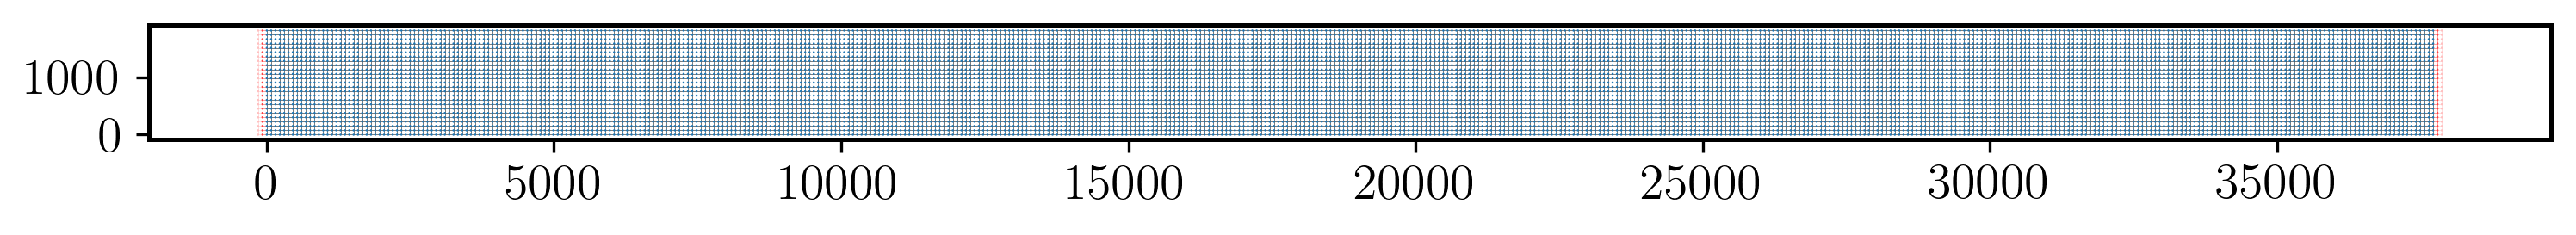

In [17]:
# wizualiuzacja układu
sys_vis = build_system(params)
kwant.plot(sys_vis, num_lead_cells=2, fig_size=(12, 4), show=False);

#### 1. policzyć relacje dyspersji $E(k)$ w kontakcie bez obecności pola magnetycznego


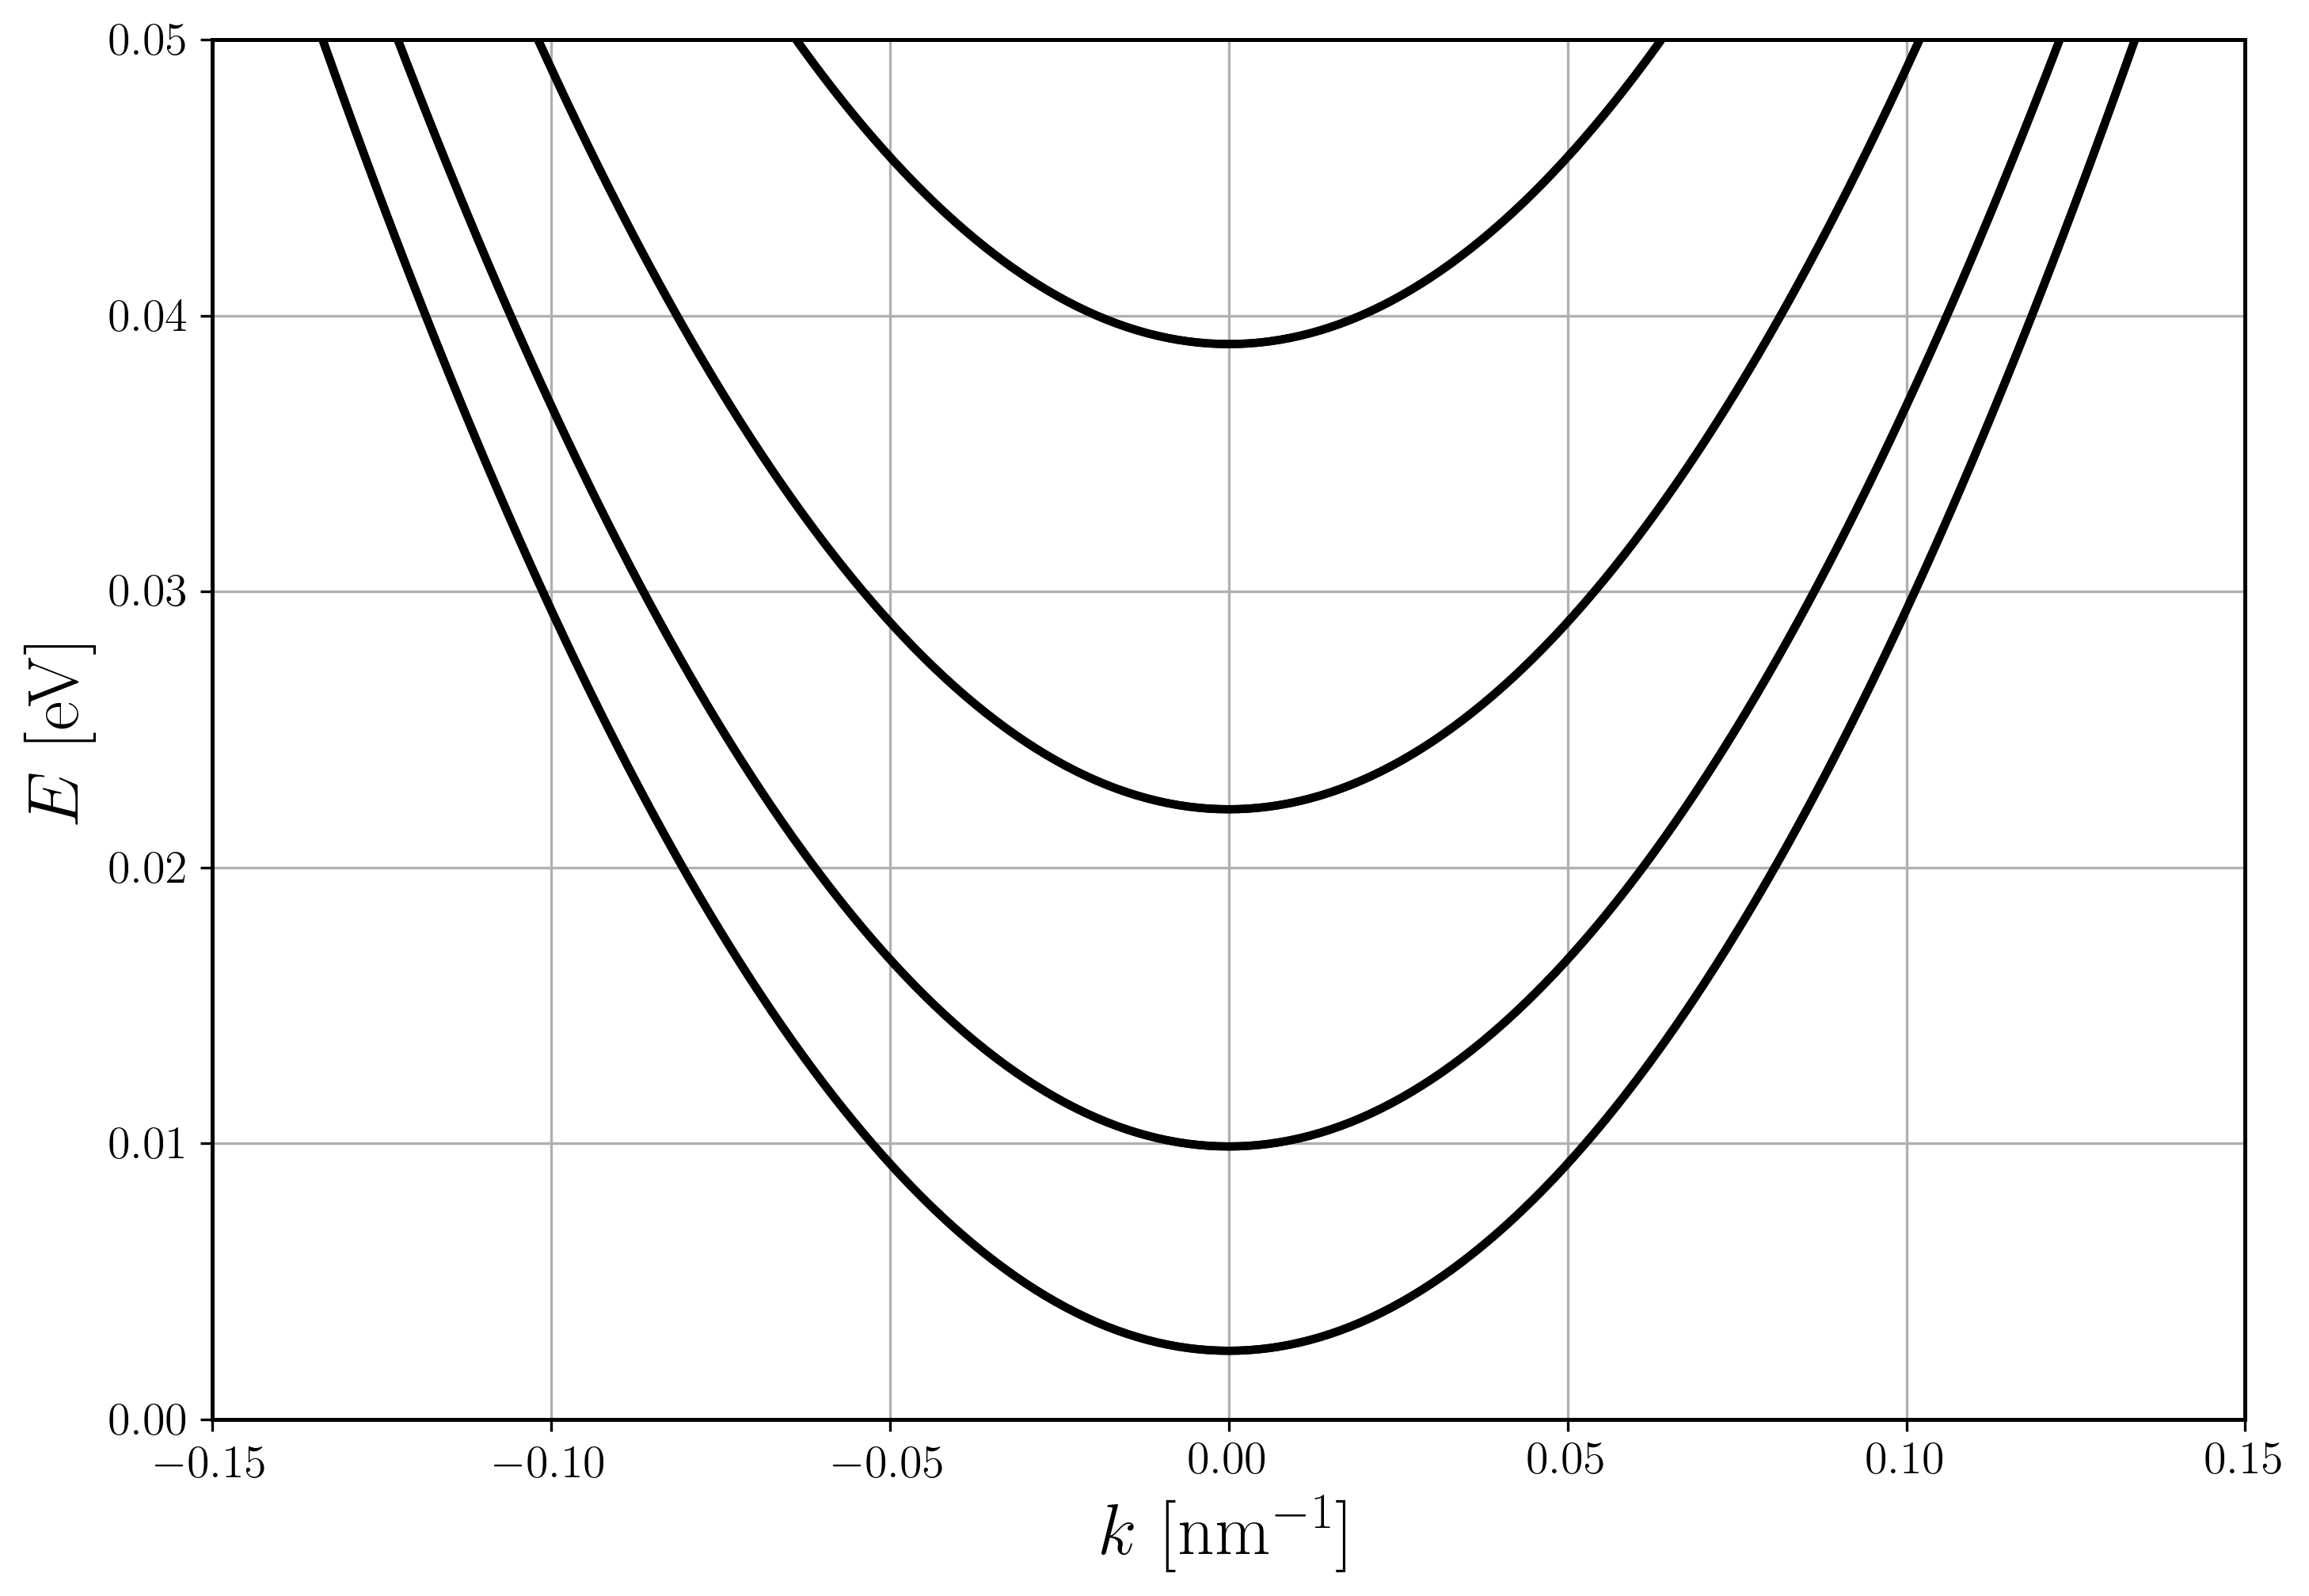

In [18]:
params.B = (0, 0, 0)
k_max, E_max = 0.15, 0.05
 
momenta, energies = compute_dispersion(params, k_max=k_max)
 
plt.figure()
plt.plot(momenta, np.array(energies) / eV_to_au(1.0), "k-")
plt.xlim(-k_max, k_max)
plt.ylim(0, E_max)
plt.xlabel(r"$k\ [\mathrm{nm}^{-1}]$")
plt.ylabel(r"$E\ [\mathrm{eV}]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_1/3_1_dispersion_noB.png", dpi=150)
plt.show()

#### 2. policzyć relacje dyspersji $E(k)$ w kontakcie dla $B = 1$ [ T ] zakładając, że pole magnetyczne przyłożone jest kolejno w kierunku osi $x, y$ oraz $z$. Czy zaobserwowane rozszczepienie Zeemana zależy od kierunku przyłożenia pola magnetycznego?

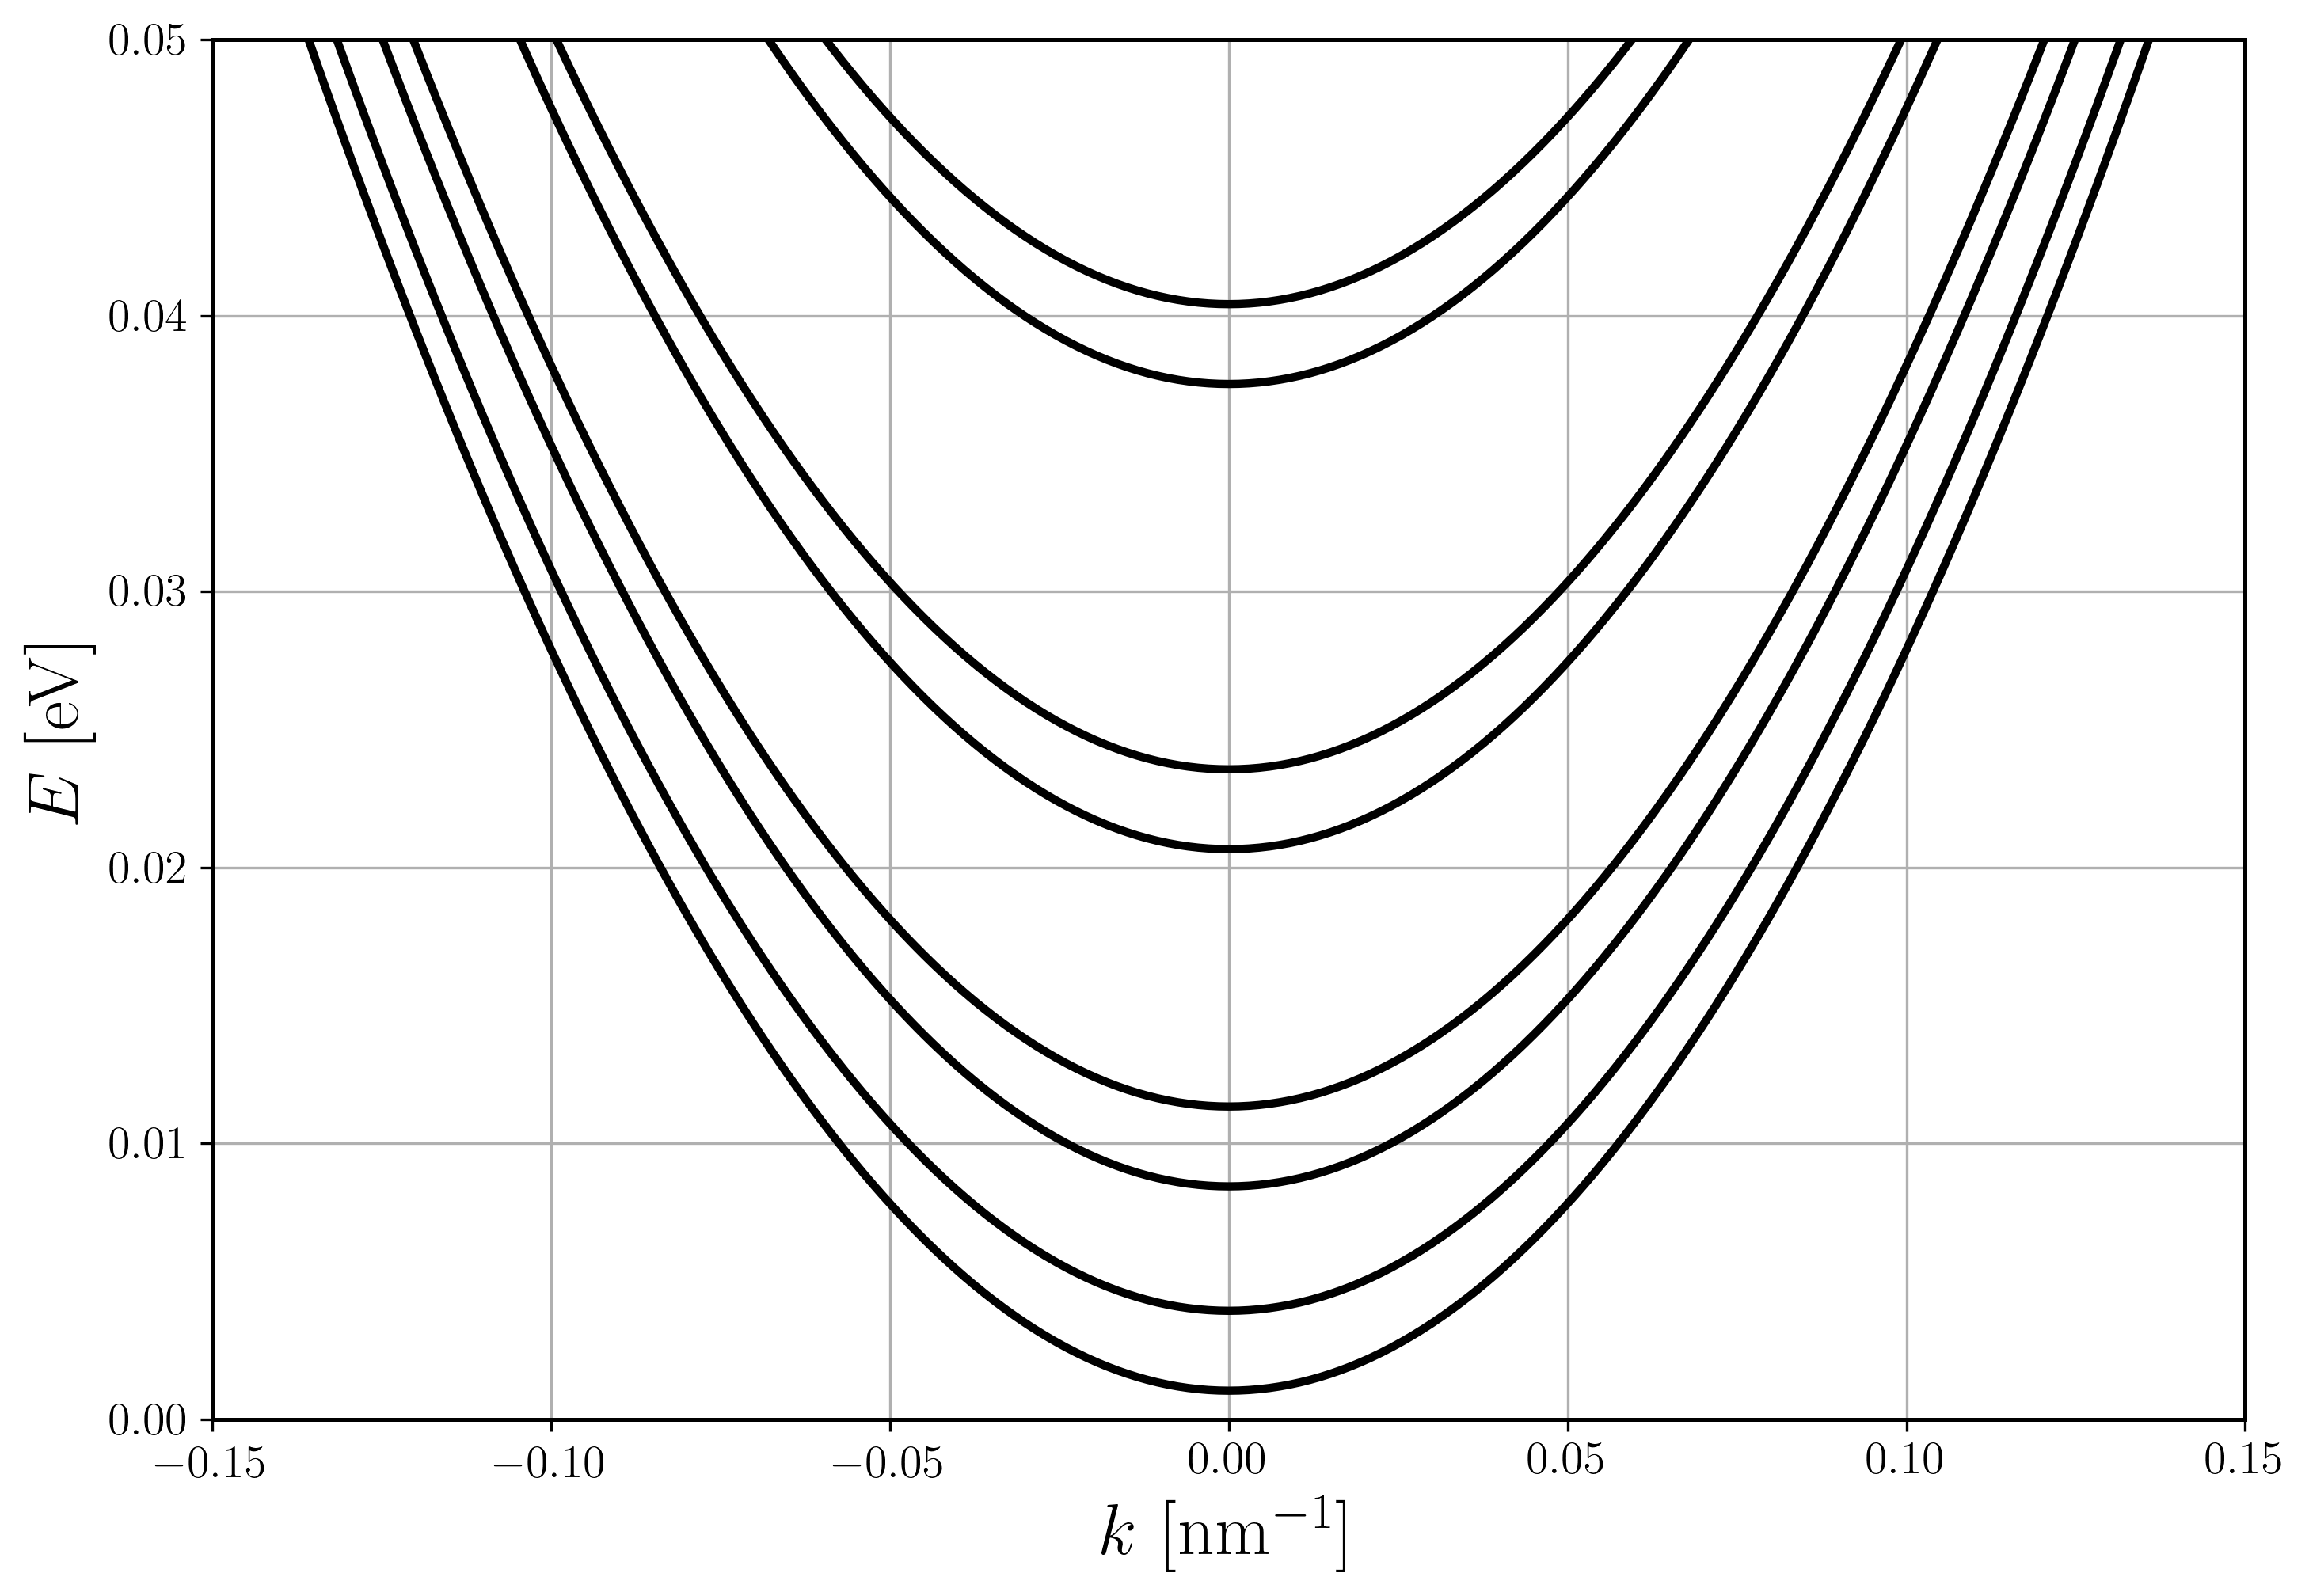

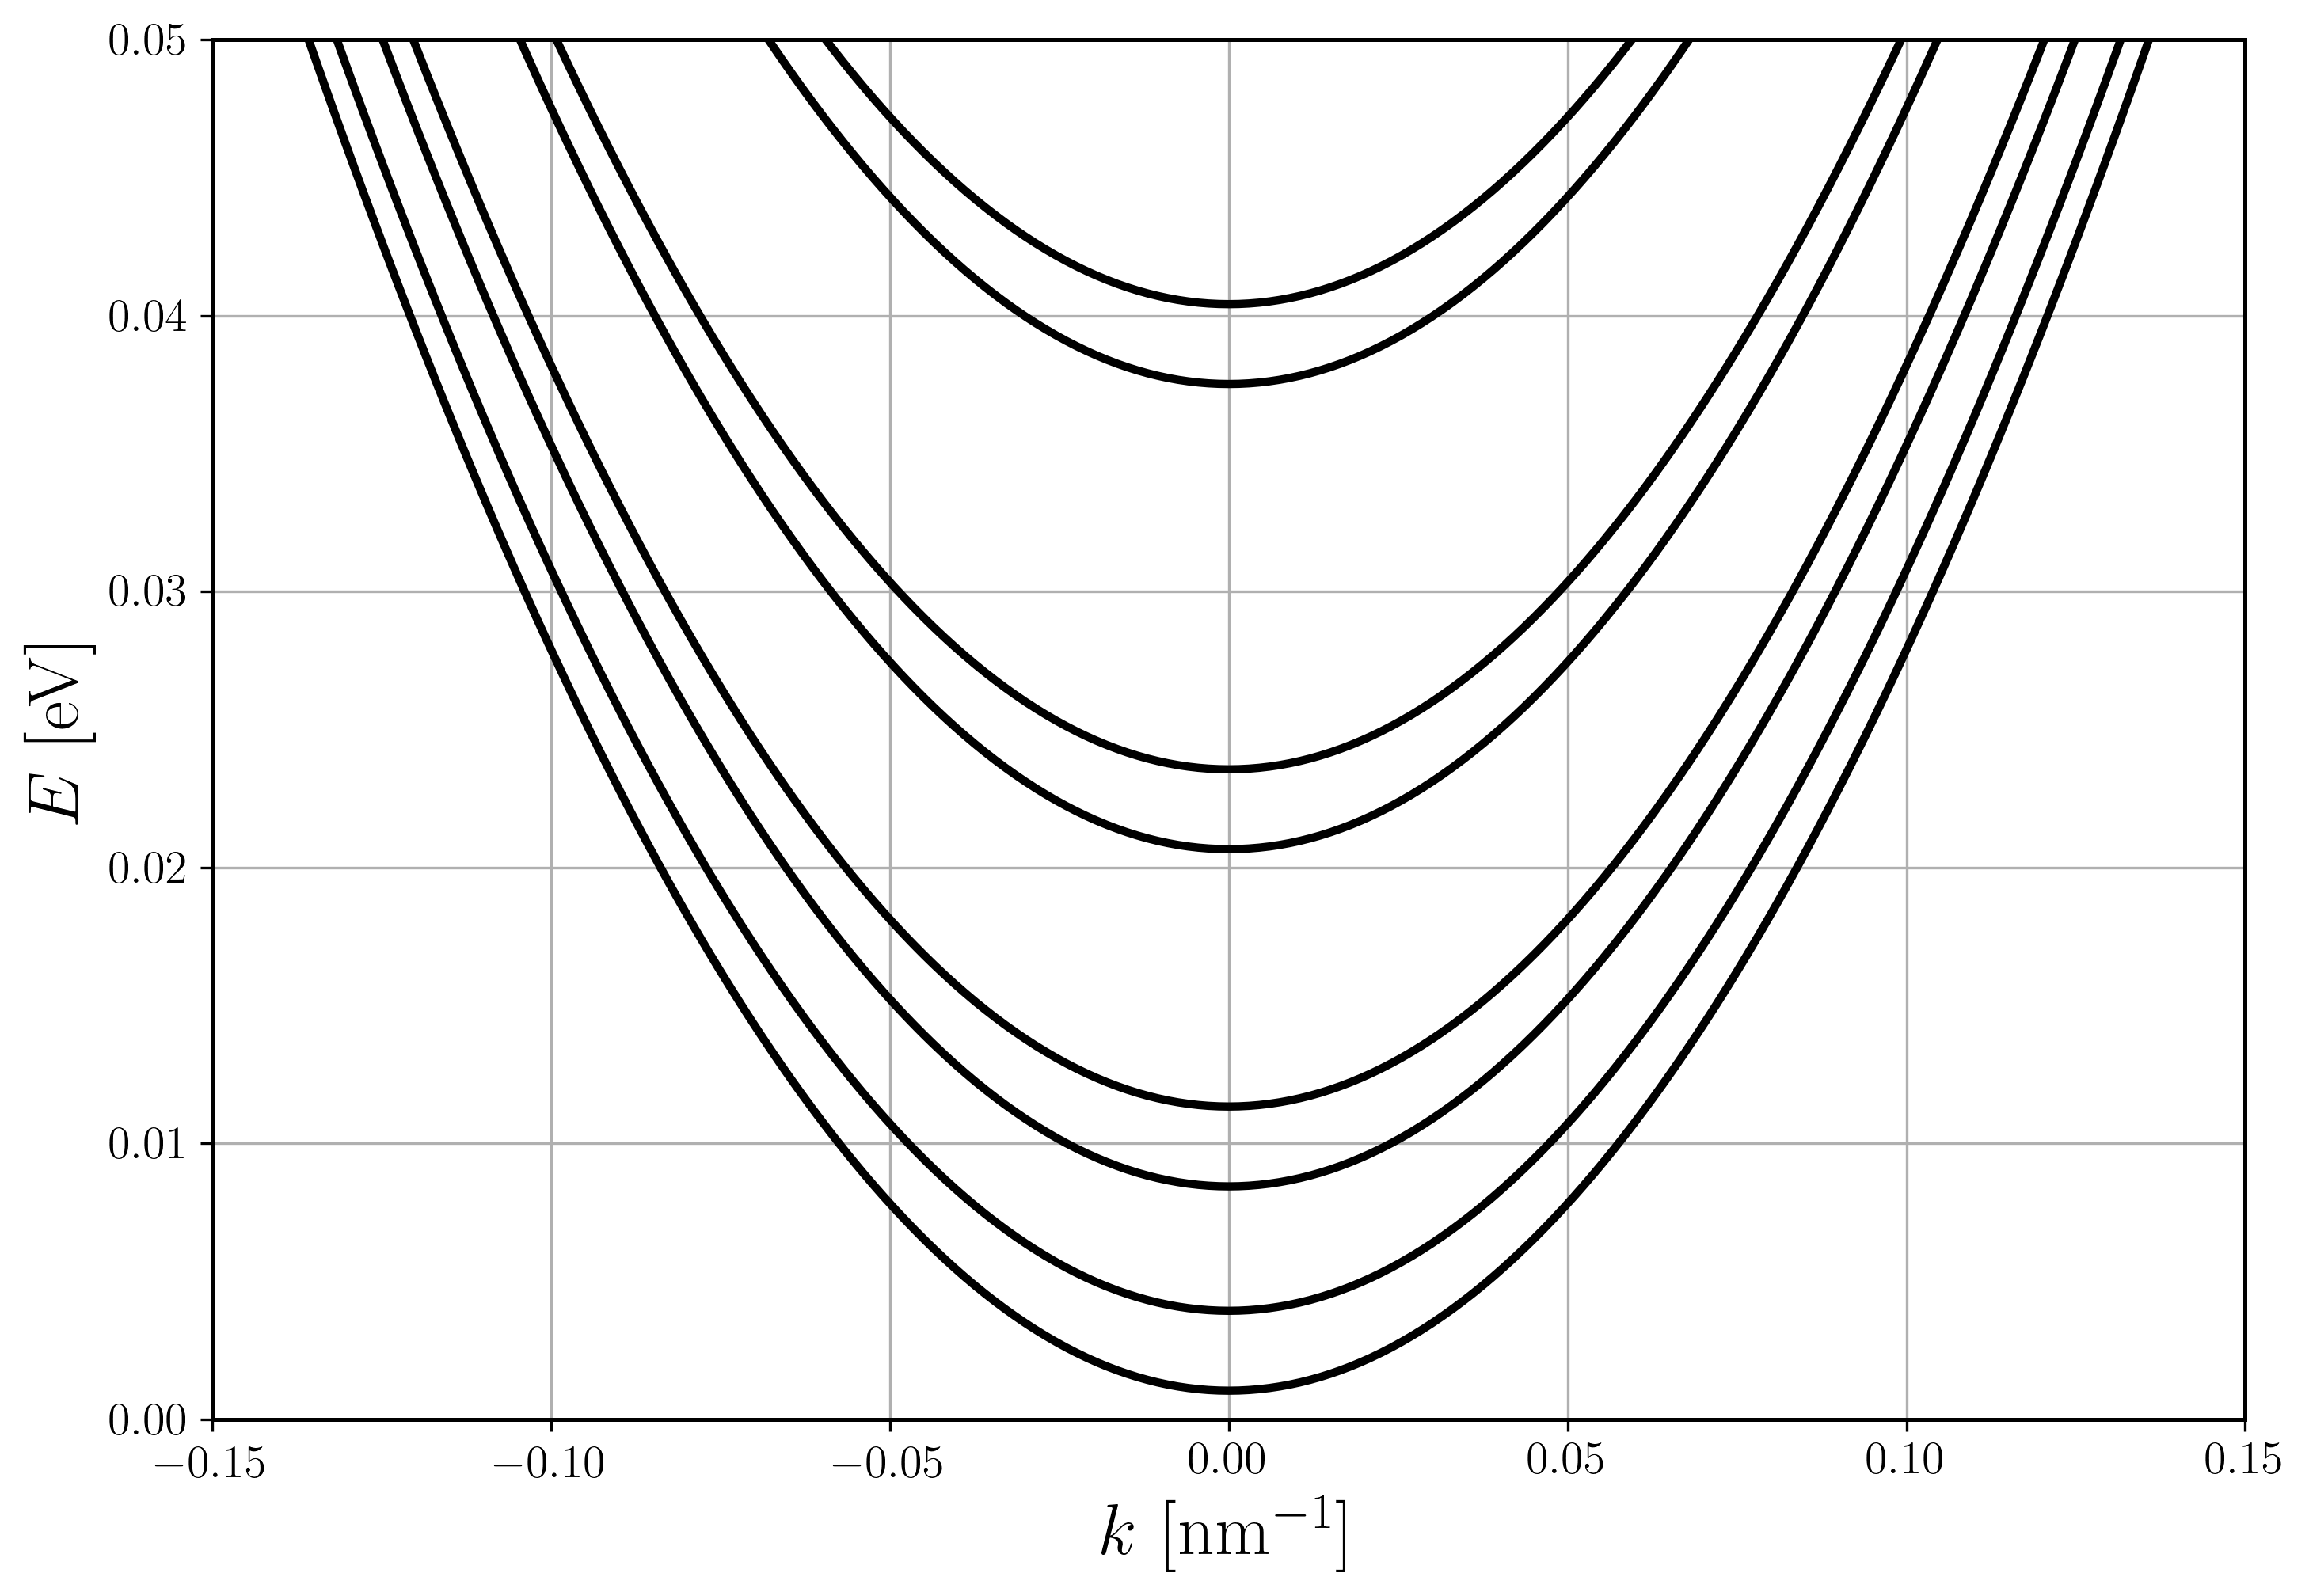

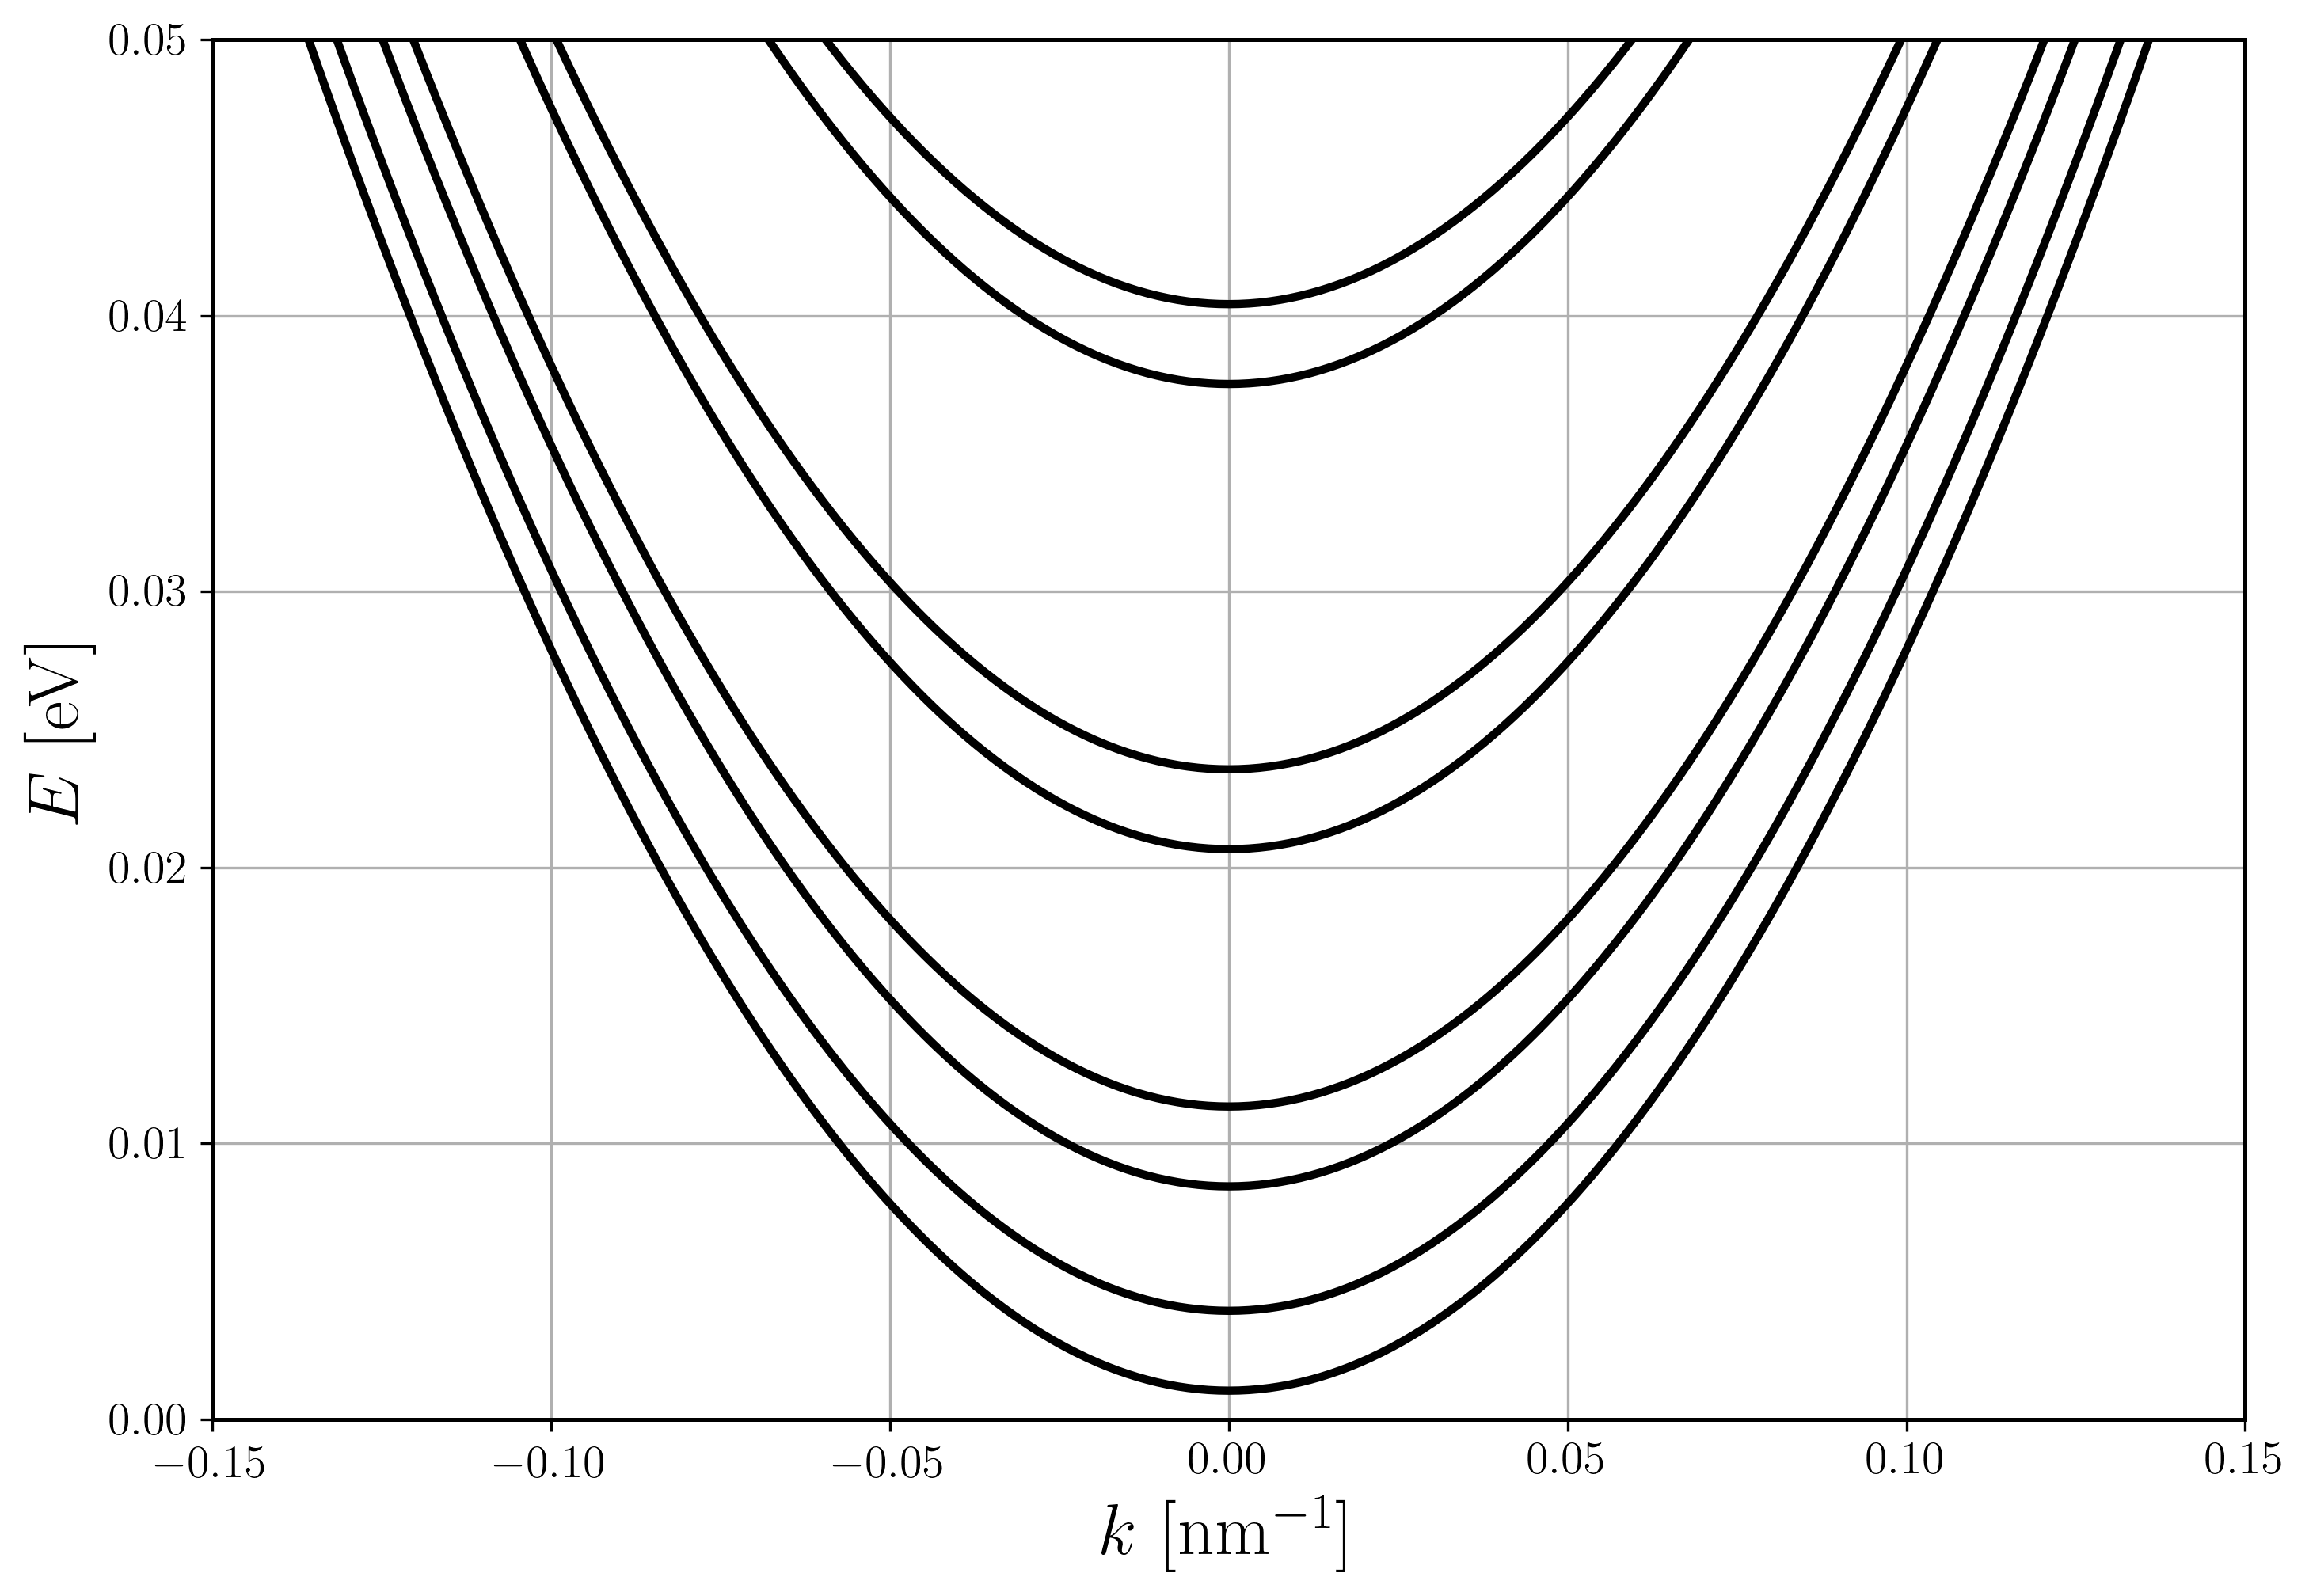

Rozszczepienie Zeemana nie zalezy od kierunku B.


In [19]:
k_max, E_max = 0.15, 0.05
 
for i, axis in enumerate(["x", "y", "z"]):
    params.B    = [0, 0, 0]
    params.B[i] = T_to_au(1.0)
    params.B    = tuple(params.B)
 
    momenta, energies = compute_dispersion(params, k_max=k_max)
 
    plt.figure()
    plt.plot(momenta, np.array(energies) / eV_to_au(1.0), "k-")
    plt.xlim(-k_max, k_max)
    plt.ylim(0, E_max)
    plt.xlabel(r"$k\ [\mathrm{nm}^{-1}]$")
    plt.ylabel(r"$E\ [\mathrm{eV}]$")
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"zad_1/3_2_dispersion_B{axis}.png", dpi=150)
    plt.show()
 
print("Rozszczepienie Zeemana nie zalezy od kierunku B.")

#### 3. przyłożyć do układu pole $B = (0, 0, B_z)$, gdzie $B_z = 1$ [ T ] i policzyć konduktancje w funkcji energii padającego elektronu,

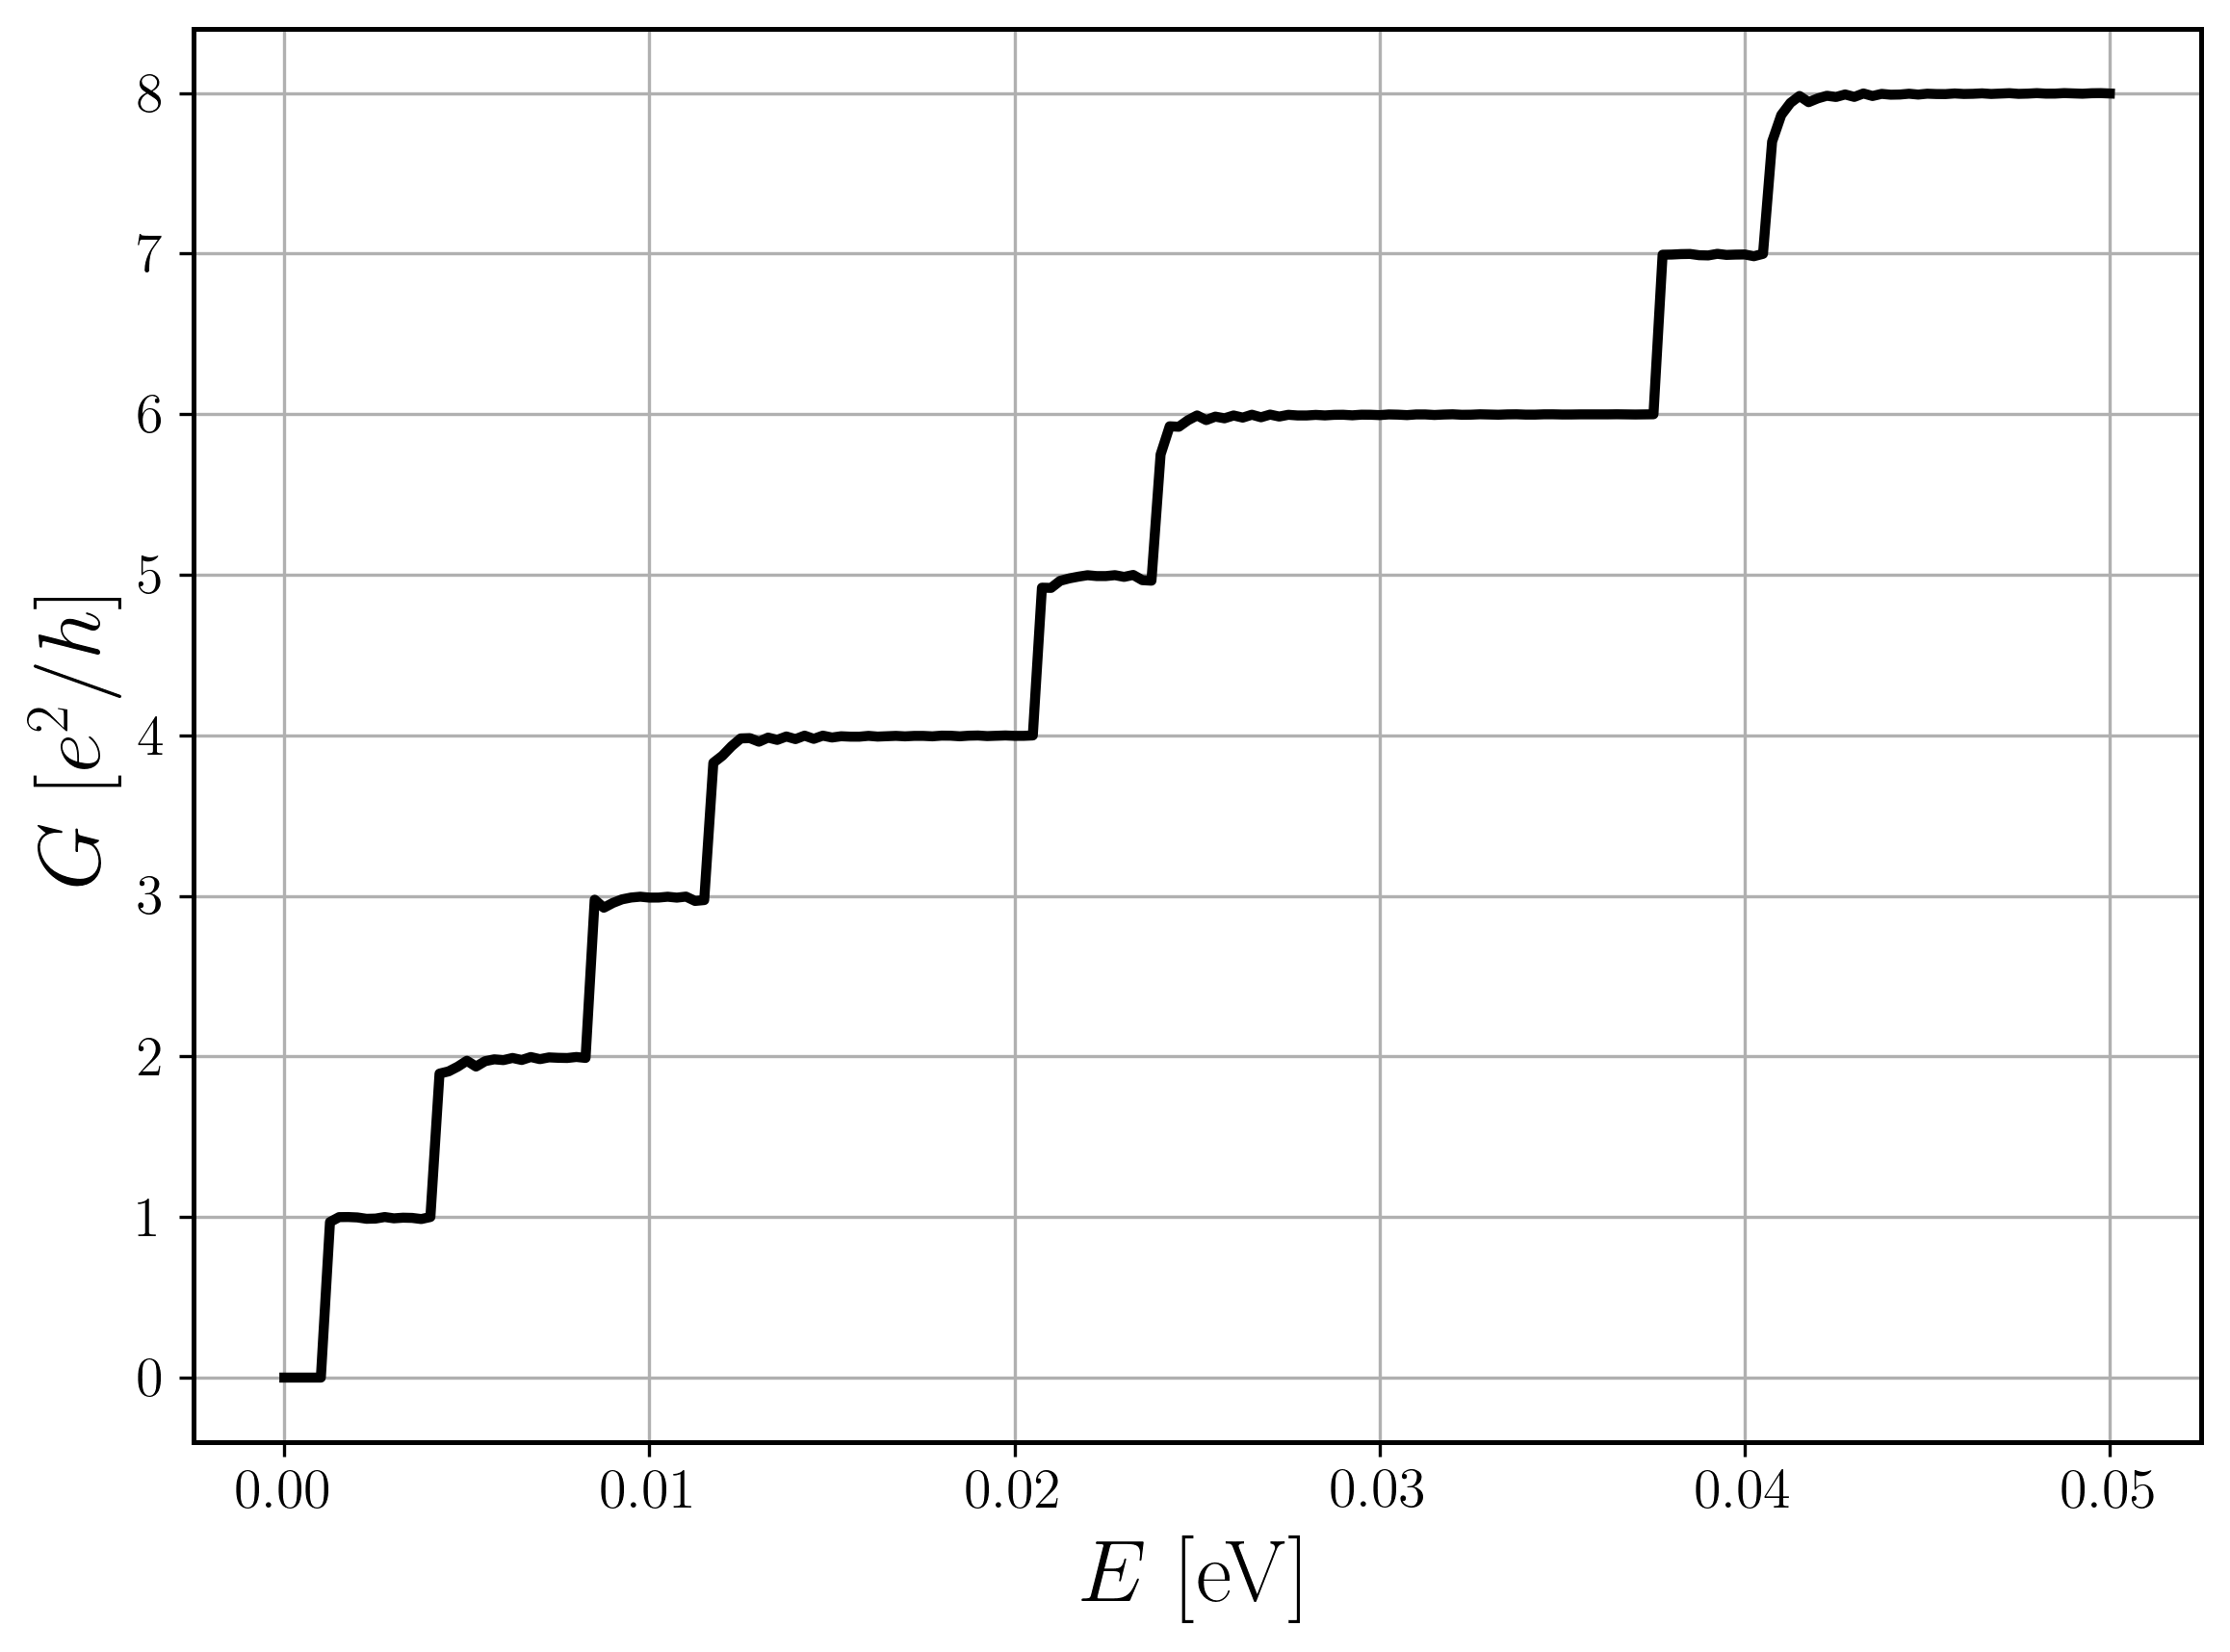

In [34]:
params.B = (0, 0, T_to_au(1.0))
 
energies_eV, cond = compute_conductance(params, E_max_eV=0.05, n_points=201)
 
plt.figure(figsize=(8, 6))
plt.plot(energies_eV, cond, "k-")
plt.xlabel(r"$E\ [\mathrm{eV}]$")
plt.ylabel(r"$G\ [e^2/h]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_1/3_3_conductance_Bz1T.png", dpi=150)
plt.show()

#### 4. przyłożyć do układu pole $B = (0, B_y , B_z)$, gdzie $B_z = 0.1$ [ T ] przyłożone jest w całym urządzeniu (łącznie z kontaktami), zaś pole $B_y$ przyłożone jest jedynie w obszarze $[0.2, 0.8] L$. Dla energii Fermiego odpowiadającej najniższemu stanowi (dla obu spinów, $E = 5$ [ meV ]) wyznaczyć współczynniki transmisji $T_{up←up}, T_{down←up} , T_{up←down}$ oraz $T_{down←down}$ w funkcji pola magnetycznego $B_y$ w zakresie od $[0, 1]$ [ T ]

In [ ]:
params.B      = (0, 0, T_to_au(0.1))
params.add_aB = True
params.area   = (0.2, 0.8, 0.0, 1.0)
 
E = eV_to_au(0.005)
n = 201
By_range = np.linspace(0, 1, n)
Tuu, Tud, Tdu, Tdd = [np.zeros(n) for _ in range(4)]
 
for i, By in enumerate(By_range):
    params.aB = (0, T_to_au(By), 0)
    sys       = build_system(params)
    sm        = kwant.smatrix(sys, E)
    Tuu[i] = sm.transmission((1, 0), (0, 0))
    Tud[i] = sm.transmission((1, 1), (0, 0))
    Tdu[i] = sm.transmission((1, 0), (0, 1))
    Tdd[i] = sm.transmission((1, 1), (0, 1))

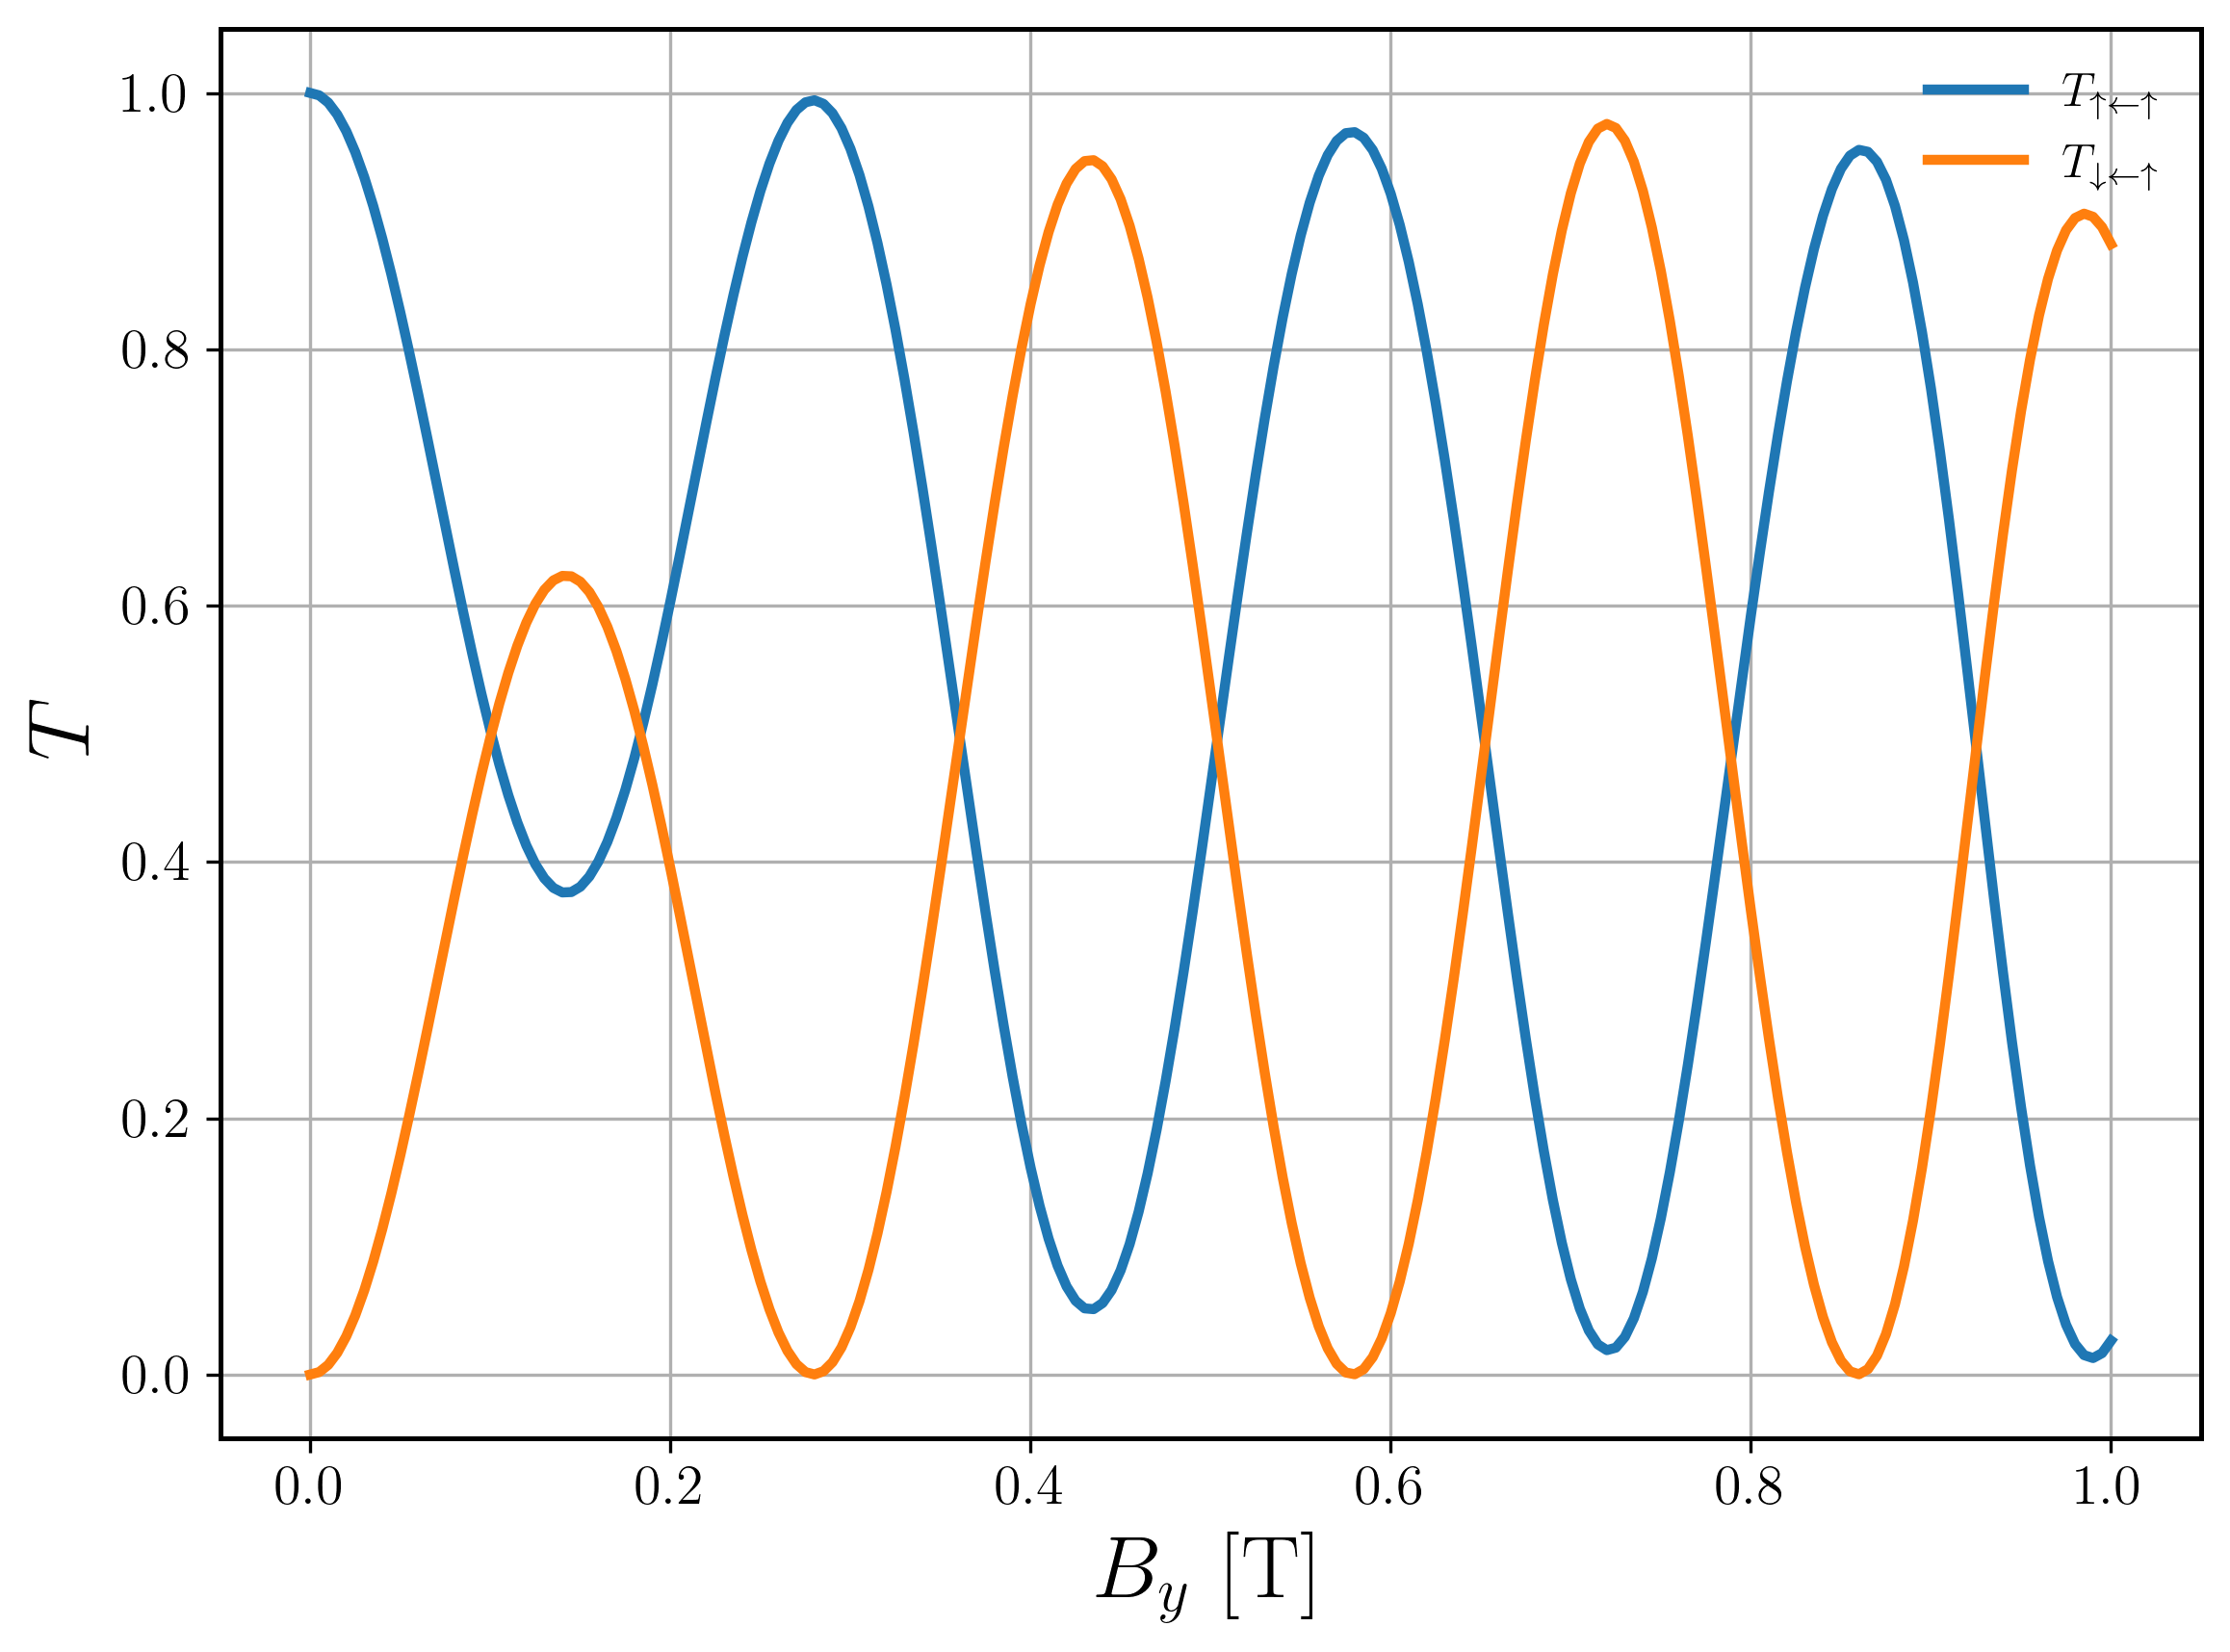

In [33]:
plt.figure(figsize=(8, 6))
plt.plot(By_range, Tuu, label=r"$T_{\uparrow\leftarrow\uparrow}$")
plt.plot(By_range, Tud, label=r"$T_{\downarrow\leftarrow\uparrow}$")
plt.xlabel(r"$B_y\ [\mathrm{T}]$")
plt.ylabel(r"$T$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("zad_1/3_4_T_up_vs_By.png", dpi=150)
plt.show()

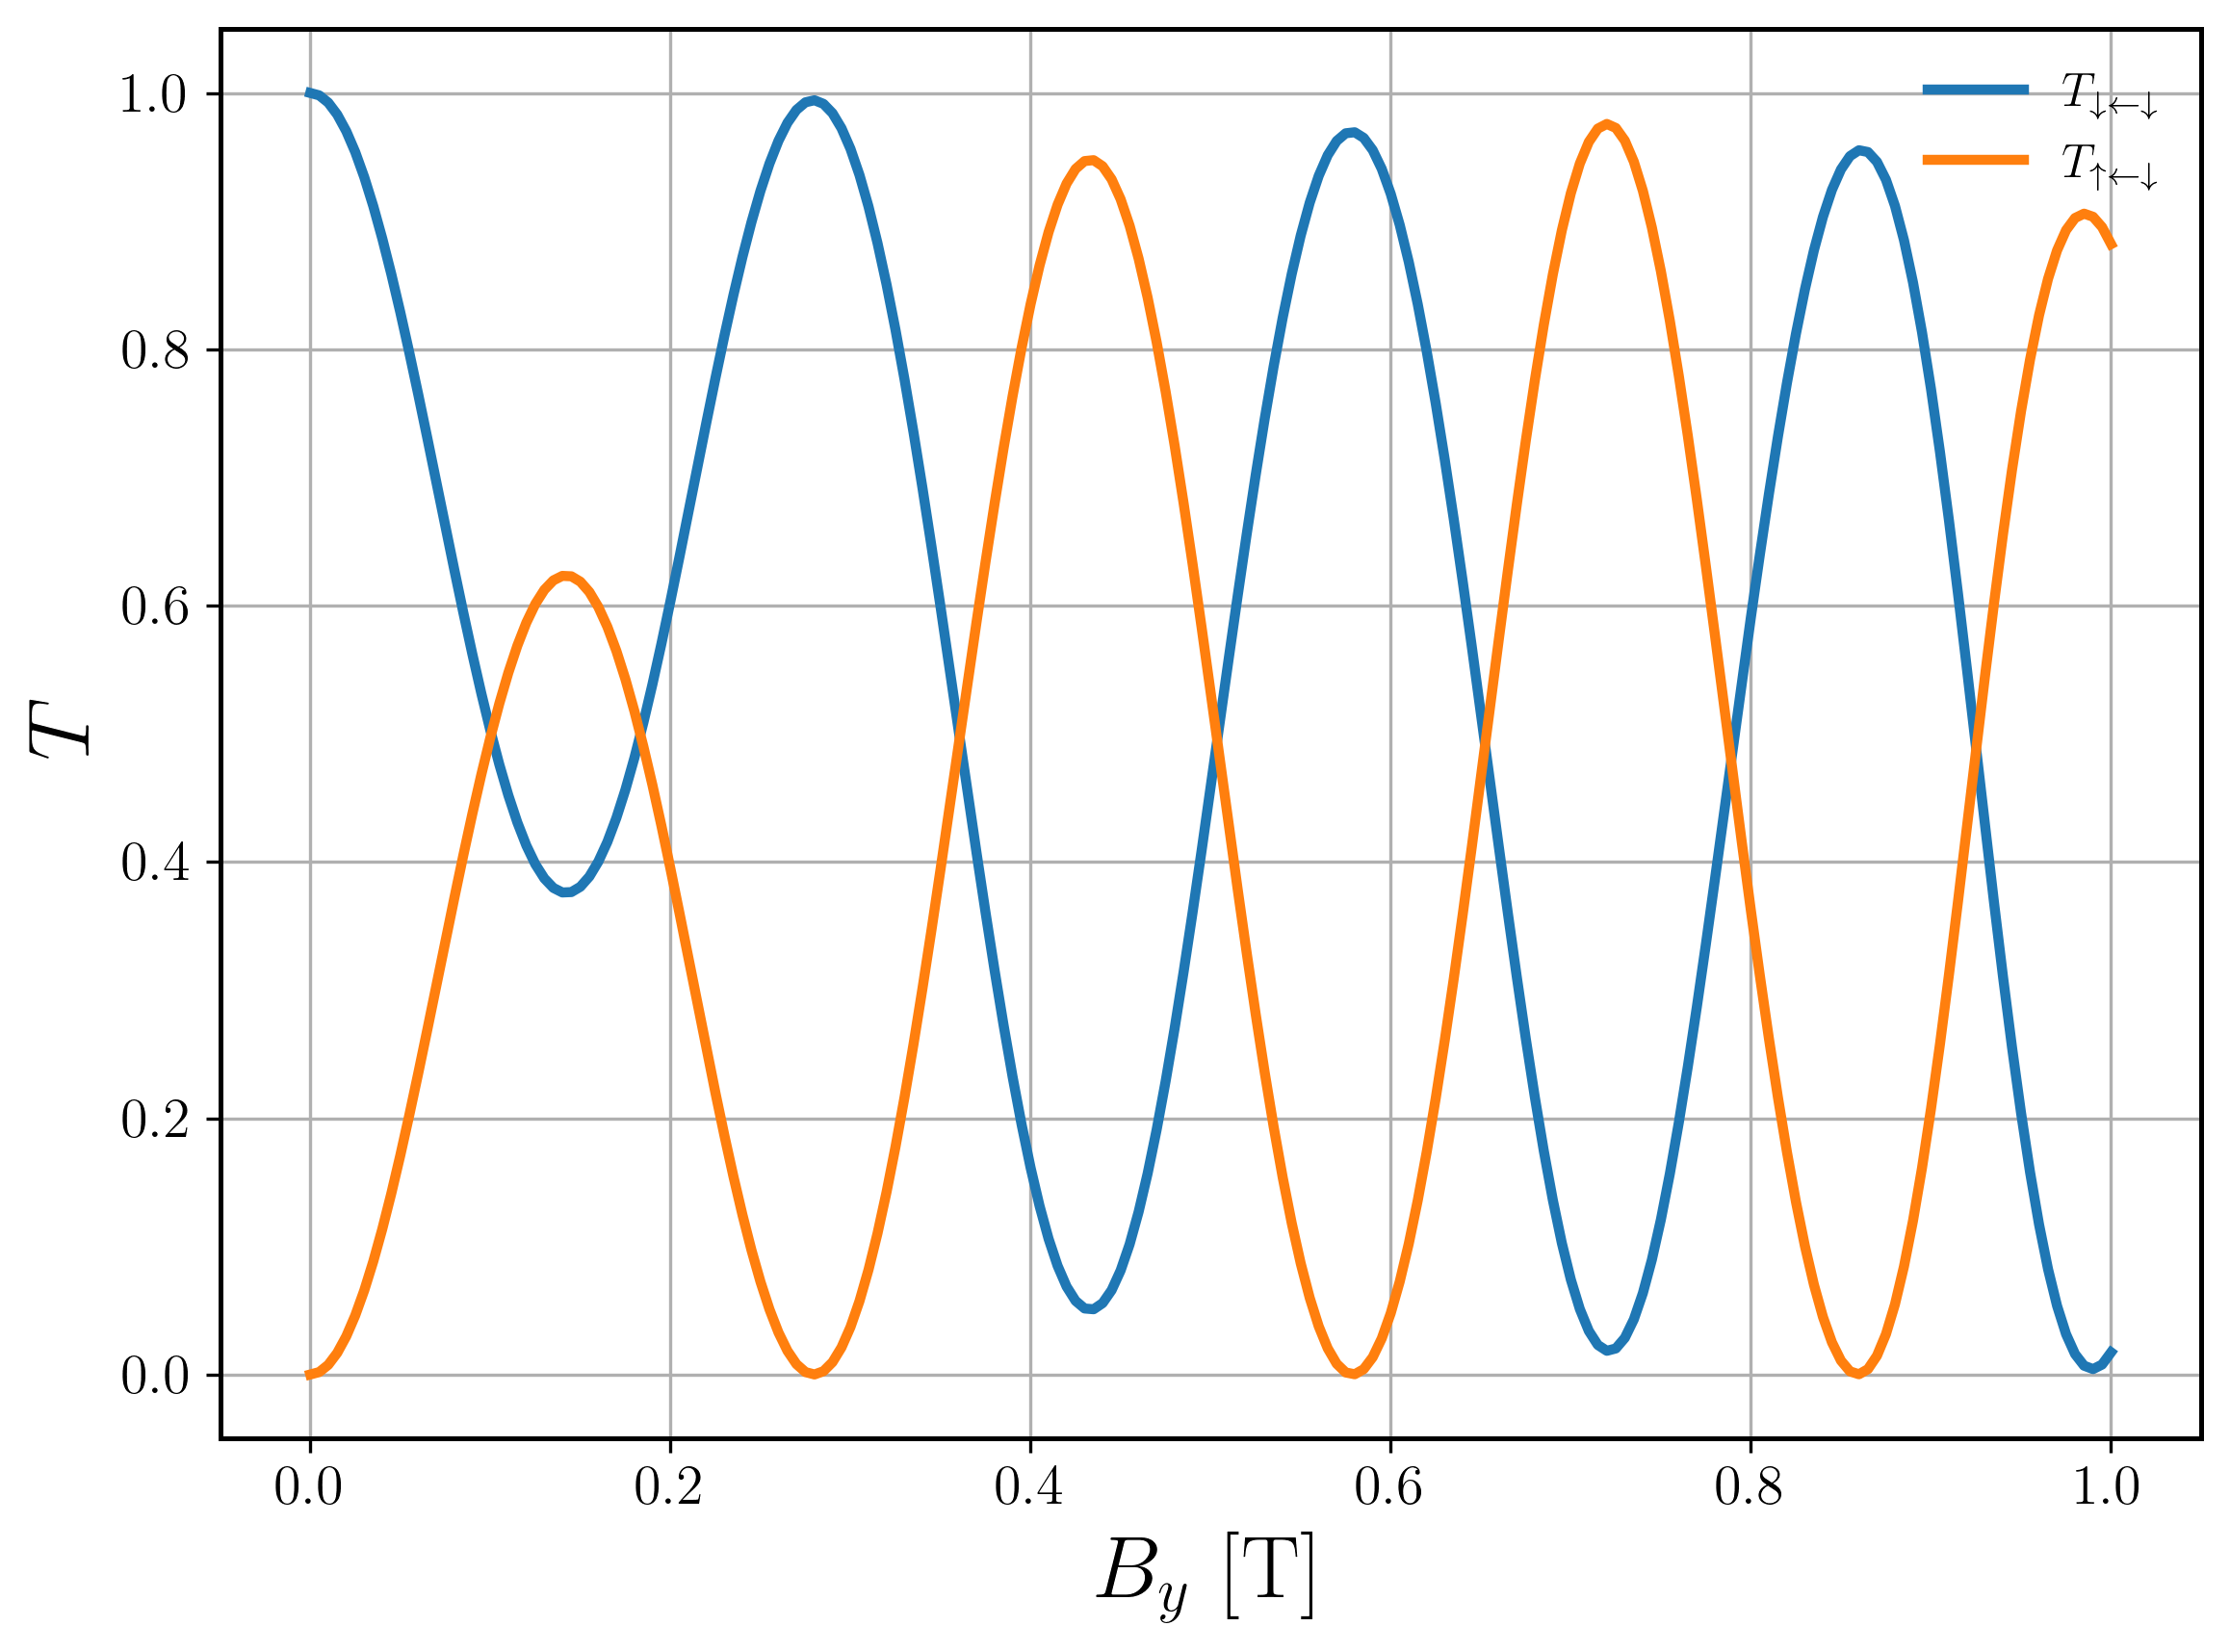

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(By_range, Tdd, label=r"$T_{\downarrow\leftarrow\downarrow}$")
plt.plot(By_range, Tdu, label=r"$T_{\uparrow\leftarrow\downarrow}$")
plt.xlabel(r"$B_y\ [\mathrm{T}]$")
plt.ylabel(r"$T$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("zad_1/3_4_T_down_vs_By.png", dpi=150)
plt.show()

#### 5. dla układu z 4. pokazać jak wygląda gęstość ładunku o spinie up i spinie down w nanourządzeniu dla elektronu wstrzykniętego w najniższym pasmie i pola $B_y = 0.6$ [ T ],

In [38]:
params.B      = (0, 0, T_to_au(0.1))
params.add_aB = True
params.area   = (0.2, 0.8, 0.0, 1.0)
params.aB     = (0, T_to_au(0.6), 0)
 
E   = eV_to_au(0.005)
sys = build_system(params)
wf  = kwant.wave_function(sys, E)(0)
 
rho_up_op   = kwant.operator.Density(sys, ta.array([[1, 0], [0, 0]]))
rho_down_op = kwant.operator.Density(sys, ta.array([[0, 0], [0, 1]]))
 
rho_up   = rho_up_op(wf[0])
rho_down = rho_down_op(wf[0])
 
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# kwant.plotter.map(sys, rho_up,   ax=ax1)
# ax1.set_title(r"Gęstość – spin $\uparrow$")
# kwant.plotter.map(sys, rho_down, ax=ax2)
# ax2.set_title(r"Gęstość – spin $\downarrow$")
# plt.tight_layout()
# plt.savefig("zad_1/3_5_density_spin_up_down.png", dpi=150)
# plt.show()

/tmp/ipykernel_12470/2615198296.py:4: RuntimeWarning: The plotted data contains 0.73% of values overflowing upper limit 49.9367 
  kwant.plotter.map(sys, rho_down, ax=ax2)


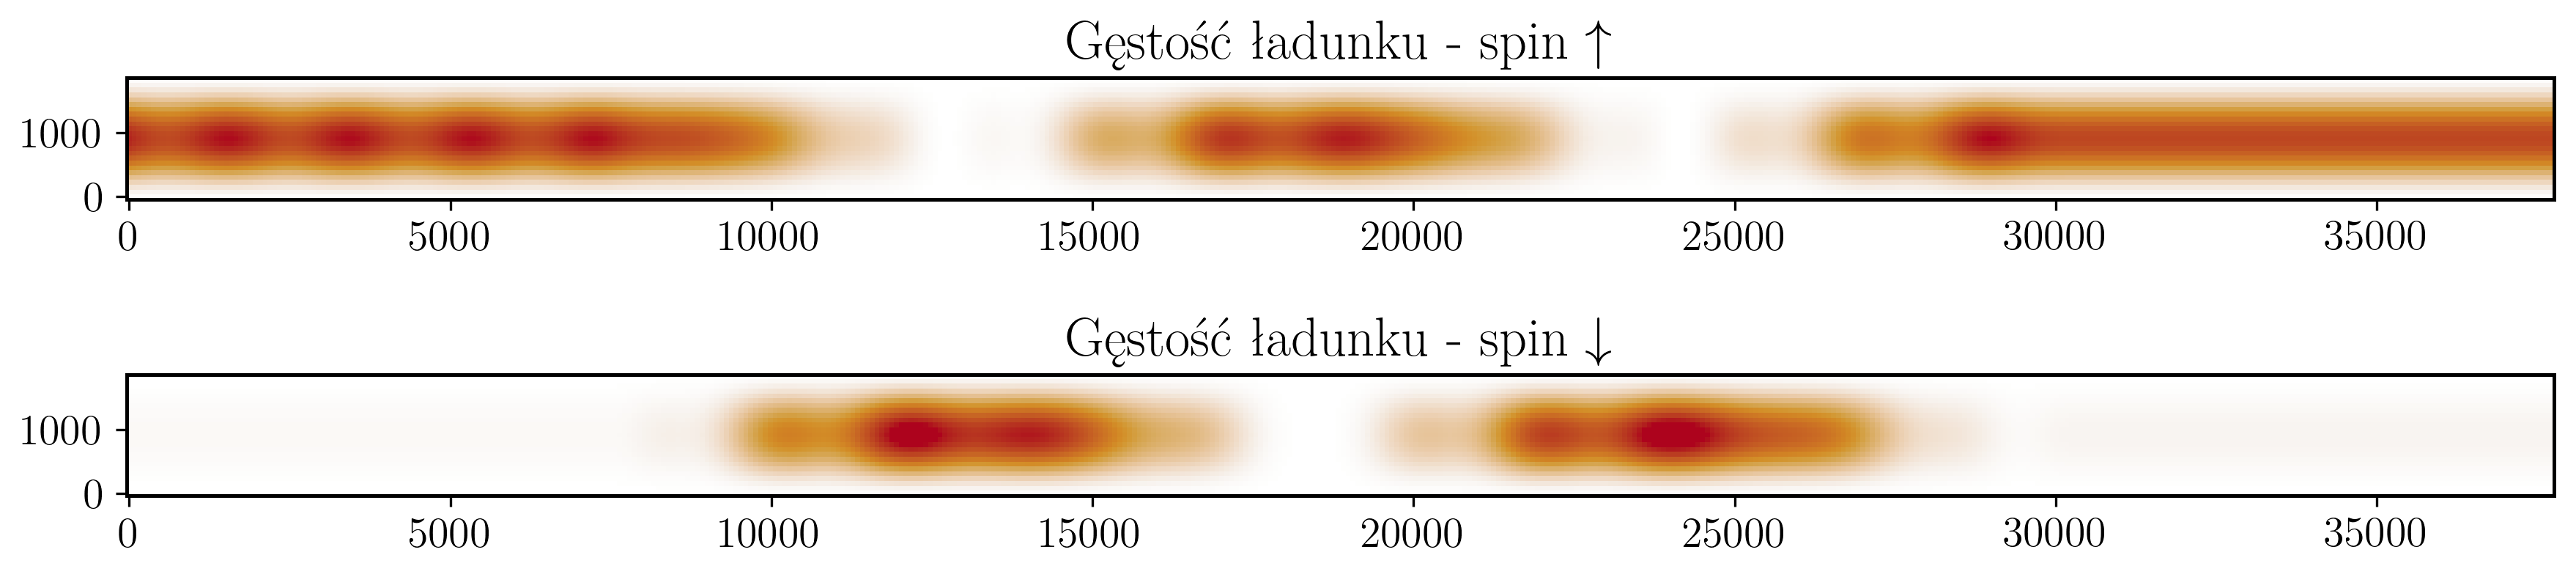

In [45]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 3))
kwant.plotter.map(sys, rho_up,   ax=ax1)
ax1.set_title(r"Gęstość ładunku - spin $\uparrow$")
kwant.plotter.map(sys, rho_down, ax=ax2)
ax2.set_title(r"Gęstość ładunku - spin $\downarrow$")
plt.tight_layout()
plt.savefig("zad_1/3_5_density_spin_up_down.png", dpi=150)
plt.show()

#### 6. dla układu z 4. pokazać jak wygląda gęstość spinu $s_x , s_y , s_z$ w nanourządzeniu dla elektronu wstrzykniętego w najniższym pasmie i pola $B_z = 0.6$ [ T ].

In [42]:
params.B      = (0, 0, T_to_au(0.1))
params.add_aB = True
params.area   = (0.2, 0.8, 0.0, 1.0)
params.aB     = (0, T_to_au(0.6), 0)
 
E   = eV_to_au(0.005)
sys = build_system(params)
wf  = kwant.wave_function(sys, E)(0)
 
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for ax, (mat, label) in zip(axes, [(sx, "$s_x$"), (sy, "$s_y$"), (sz, "$s_z$")]):
#     spin_map = kwant.operator.Density(sys, mat)(wf[0])
#     kwant.plotter.map(sys, spin_map, cmap="seismic", ax=ax)
#     ax.set_title(f"Gęstość spinu {label}")
# plt.tight_layout()
# plt.savefig("zad_1/3_6_spin_density.png", dpi=150)
# plt.show()

/tmp/ipykernel_12470/1943605174.py:4: RuntimeWarning: The plotted data contains 0.38% of values overflowing upper limit 52.7937 and 0.65% of values underflowing lower limit -51.8019 
  kwant.plotter.map(sys, spin_map, cmap="seismic", ax=ax)
/tmp/ipykernel_12470/1943605174.py:4: RuntimeWarning: The plotted data contains 0.25% of values overflowing upper limit 15.5214 and 0.58% of values underflowing lower limit -16.5034 
  kwant.plotter.map(sys, spin_map, cmap="seismic", ax=ax)
/tmp/ipykernel_12470/1943605174.py:4: RuntimeWarning: The plotted data contains 0.18% of values underflowing lower limit -52.1809 
  kwant.plotter.map(sys, spin_map, cmap="seismic", ax=ax)


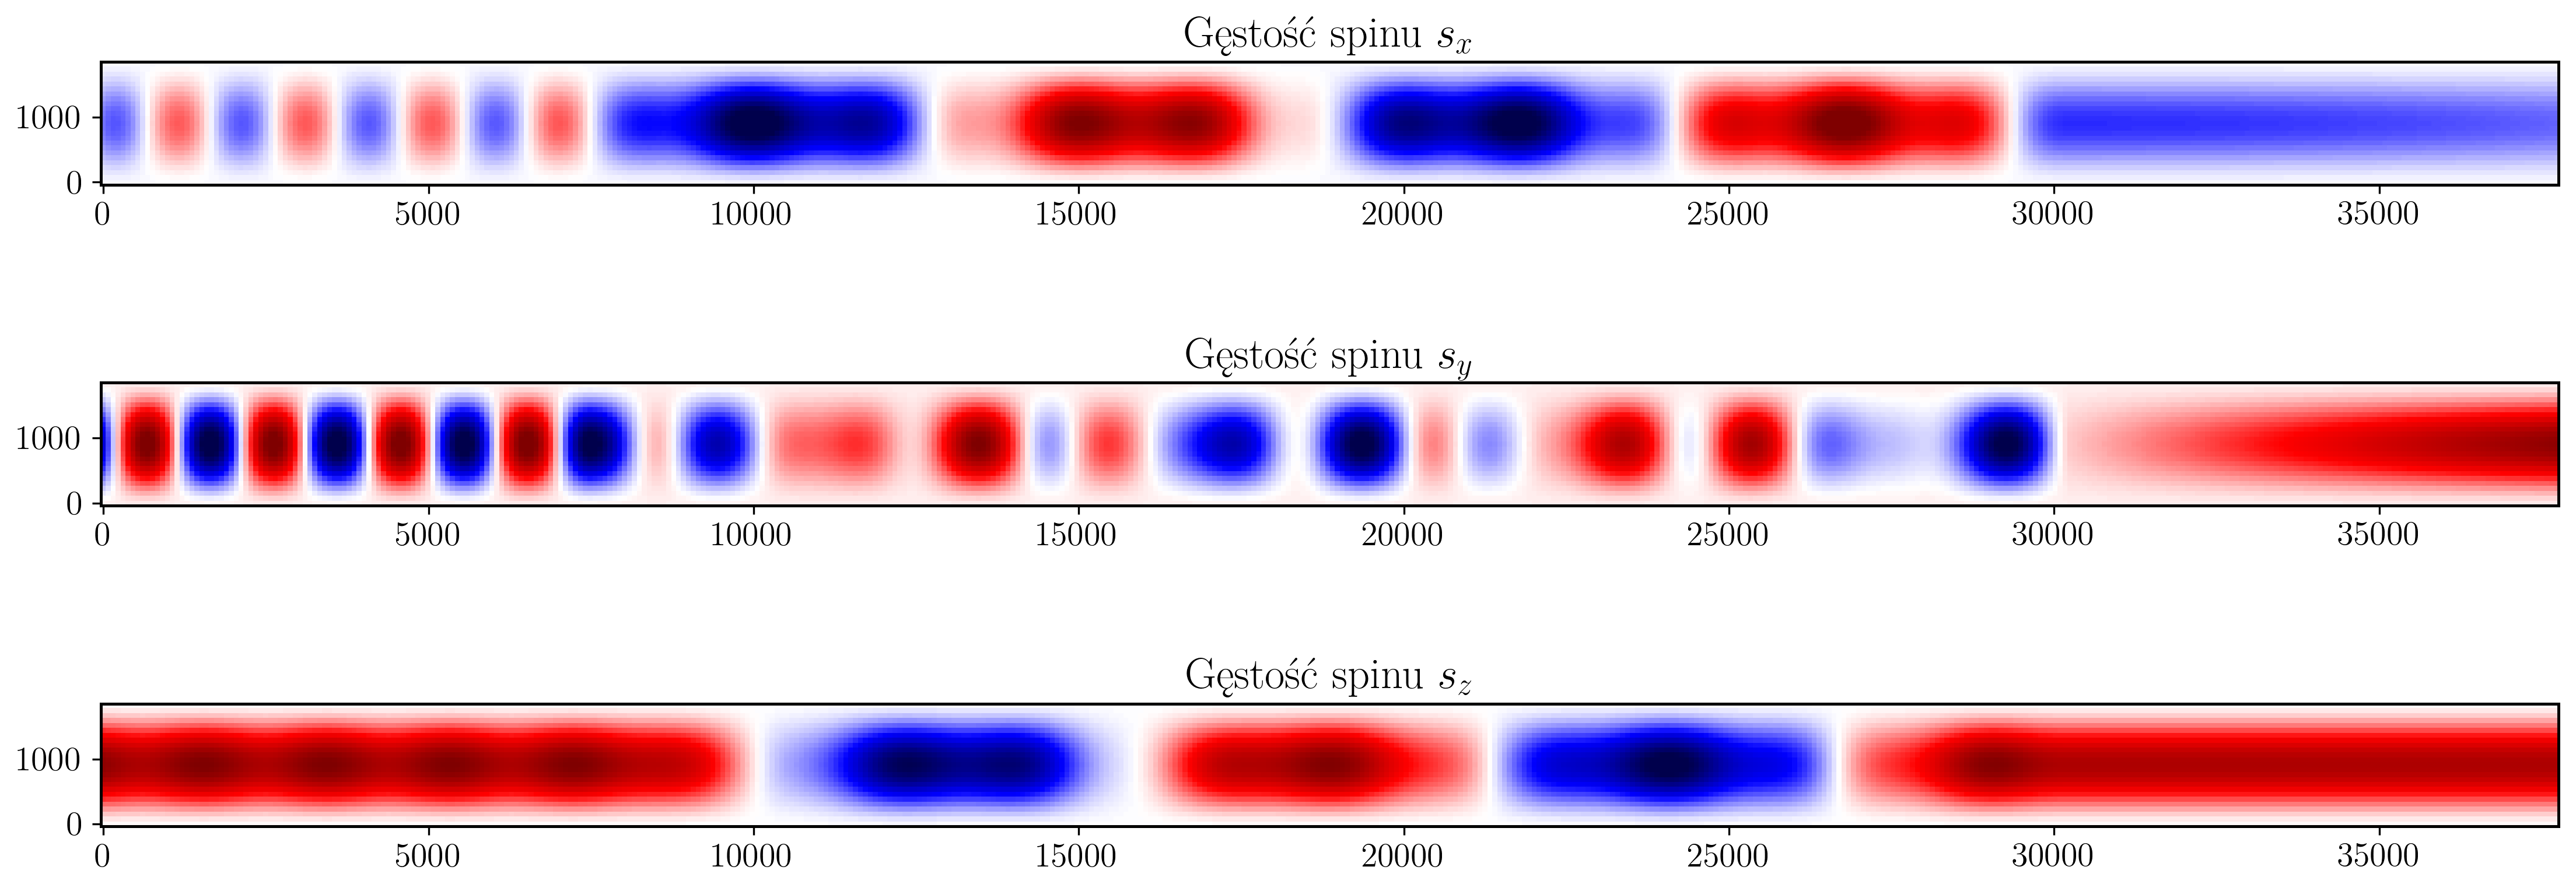

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(15, 6))
for ax, (mat, label) in zip(axes, [(sx, "$s_x$"), (sy, "$s_y$"), (sz, "$s_z$")]):
    spin_map = kwant.operator.Density(sys, mat)(wf[0])
    kwant.plotter.map(sys, spin_map, cmap="seismic", ax=ax)
    ax.set_title(f"Gęstość spinu {label}")
plt.tight_layout()
plt.savefig("zad_1/3_6_spin_density.png", dpi=150)
plt.show()